# Maize Price Forecasting Pipeline

Step-by-step notebook from data loading to Streamlit deployment.

**Sections:**
1. Project Setup & Imports
2. Raw Data Loading
3. Data Cleaning (Pandas 3.x Compatible)
4. Data Merging & Price Priority
5. Feature Engineering (37 Features)
6. Exploratory Data Analysis
7. Δ-Price Target & Expanding Window CV
8. Pooled XGBoost (All Counties)
9. Per-County Fine-Tuning
10. Persistence Baseline
11. Model Evaluation (MASE, Dir Acc, MAE, sMAPE)
12. Save Pooled Model & Config
13. Streamlit Dashboard Development
14. Deployment Instructions
15. Summary & Next Steps

## Section 1: Project Setup & Imports

This section installs required packages and imports all necessary libraries for the maize price forecasting pipeline.

### Step 1.1: Install Required Packages

Run this cell to install all required packages. Uncomment the lines if packages are not installed.

In [1]:
# Uncomment and run if packages need to be installed
!pip install pandas numpy scikit-learn xgboost statsmodels streamlit matplotlib seaborn joblib openpyxl

print('Packages ready!')

Packages ready!



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1.2: Import Libraries

Import all required libraries for data processing, modeling, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# XGBoost
import xgboost as xgb

# Statsmodels for SARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as tsa

# Joblib for model saving
import joblib

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print('All libraries imported successfully!')

All libraries imported successfully!


### Step 1.3: Set Up Path Constants

Define all directory paths used throughout the pipeline.

In [3]:
# Define base directory
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if not (BASE_DIR / 'data').exists():
    BASE_DIR = Path('C:/Users/Administrator/Desktop/MAIZE PROJECT/maize-forecasting')

# Define directory paths
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
FEATURES_DIR = DATA_DIR / 'features'
MODELS_DIR = BASE_DIR / 'models'
SRC_DIR = BASE_DIR / 'src'
DASHBOARD_DIR = SRC_DIR / 'dashboard'

# Create directories if they don't exist
for dir_path in [RAW_DIR, PROCESSED_DIR, FEATURES_DIR, MODELS_DIR, DASHBOARD_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Data directory: {DATA_DIR}')
print(f'Raw data directory: {RAW_DIR}')
print(f'Models directory: {MODELS_DIR}')

Base directory: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting
Data directory: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data
Raw data directory: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data\raw
Models directory: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\models


# Section 2: Raw Data Loading

Load the three raw datasets: KAMIS price data, AgriBORA price data, and weather data.

### Step 2.1: Load KAMIS Price Data

The KAMIS (Kenya Agricultural Market Information System) dataset contains weekly price data for various commodities across Kenyan markets.

In [4]:
# Load KAMIS data
kamis_path = RAW_DIR / 'kamis_maize_prices.csv'
print(f'Loading KAMIS data from: {kamis_path}')

kamis_df = pd.read_csv(kamis_path)
print(f'\nKAMIS data shape: {kamis_df.shape}')
print(f'\nKAMIS columns: {list(kamis_df.columns)}')
print(f'\nFirst 3 rows:')
display(kamis_df.head(3))

Loading KAMIS data from: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data\raw\kamis_maize_prices.csv

KAMIS data shape: (21888, 15)

KAMIS columns: ['Commodity_Classification', 'Commodity', 'Classification', 'County', 'Market', 'Date', 'Year', 'Month', 'Year_Month', 'WeekofYear', 'Year_Week', 'SupplyVolume', 'Retail', 'Wholesale', 'Unit']

First 3 rows:


,Commodity_Classification,Commodity,Classification,County,Market,Date,Year,Month,Year_Month,WeekofYear,Year_Week,SupplyVolume,Retail,Wholesale,Unit
0,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Kabarnet_Market,2021-05-24,2021,5,2021-05,21,2021-21,2700.0,30.0,25.0,Kg
1,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Marigat_Market,2021-05-24,2021,5,2021-05,21,2021-21,14000.0,30.0,27.0,Kg
2,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Marigat_Market,2021-05-24,2021,5,2021-05,21,2021-21,14000.0,30.0,27.0,Kg


### Step 2.2: Load AgriBORA Price Data

AgriBORA provides transaction-based price data, which is more accurate than survey-based data.

In [5]:
# Load AgriBORA data
agribora_path = RAW_DIR / 'agriBORA_maize_prices.csv'
print(f'Loading AgriBORA data from: {agribora_path}')

agribora_df = pd.read_csv(agribora_path)
print(f'\nAgriBORA data shape: {agribora_df.shape}')
print(f'\nAgriBORA columns: {list(agribora_df.columns)}')
print(f'\nFirst 3 rows:')
display(agribora_df.head(3))

Loading AgriBORA data from: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data\raw\agriBORA_maize_prices.csv

AgriBORA data shape: (239, 6)

AgriBORA columns: ['County', 'Date', 'WholeSale', 'Commodity_Classification', 'Year_Week', 'WeekofYear']

First 3 rows:


,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
0,Kirinyaga,2023-10-02,48.89,Dry_White_Maize,2023-40,40
1,Nairobi,2023-10-02,49.63,Dry_White_Maize,2023-40,40
2,Uasin-Gishu,2023-10-02,46.67,Dry_White_Maize,2023-40,40


### Step 2.3: Load Weather Data

Weather data includes temperature and rainfall measurements for various counties in Kenya.

In [6]:
# Load Weather data
weather_path = RAW_DIR / 'weather_kenya_all_counties_2021_2025 (2).csv'
print(f'Loading Weather data from: {weather_path}')

weather_df = pd.read_csv(weather_path)
print(f'\nWeather data shape: {weather_df.shape}')
print(f'\nWeather columns: {list(weather_df.columns)}')
print(f'\nFirst 3 rows:')
display(weather_df.head(3))

Loading Weather data from: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data\raw\weather_kenya_all_counties_2021_2025 (2).csv

Weather data shape: (88877, 12)

Weather columns: ['county', 'latitude', 'longitude', 'date', 'temp_max_c', 'temp_min_c', 'temp_avg_c', 'precipitation_mm', 'rain_mm', 'precipitation_hours', 'wind_speed_max_kmh', 'wind_gusts_max_kmh']

First 3 rows:


,county,latitude,longitude,date,temp_max_c,temp_min_c,temp_avg_c,precipitation_mm,rain_mm,precipitation_hours,wind_speed_max_kmh,wind_gusts_max_kmh
0,Baringo,0.4667,36.0833,2021-01-01,31.5,17.9,23.9,2.3,2.3,5.0,18.4,40.7
1,Baringo,0.4667,36.0833,2021-01-02,32.7,19.1,26.3,0.0,0.0,0.0,17.3,38.5
2,Baringo,0.4667,36.0833,2021-01-03,33.5,19.0,27.0,0.0,0.0,0.0,22.3,44.3


# Section 3: Data Cleaning (Pandas 3.x Compatible)

Clean all three datasets using pandas 3.x compatible syntax. Key change: use `.ffill().bfill()` instead of `fillna(method='ffill')`.

### Step 3.1: Clean KAMIS Data

**Steps:**
1. Filter for White Maize only
2. Standardize column names
3. Clean county names
4. Convert date columns to datetime
5. Handle missing values with forward-fill then backward-fill

In [7]:
# Clean KAMIS data
print('='*50)
print('CLEANING KAMIS DATA')
print('='*50)

# Make a copy and standardize column names first
kamis_clean = kamis_df.copy()
kamis_clean.columns = [col.strip().lower().replace(' ', '_') for col in kamis_clean.columns]
print(f'\nStandardized columns: {list(kamis_clean.columns)}')

# Display available maize categories
if 'commodity' in kamis_clean.columns:
    print(f'Unique commodities: {kamis_clean["commodity"].unique()}')
if 'classification' in kamis_clean.columns:
    print(f'Unique classifications: {kamis_clean["classification"].unique()}')
if 'commodity_classification' in kamis_clean.columns:
    print(f'Unique commodity classifications: {kamis_clean["commodity_classification"].unique()}')

# Filter for White Maize. In this file, Commodity is Dry_Maize and Classification is White_Maize.
if 'classification' in kamis_clean.columns:
    kamis_clean = kamis_clean[kamis_clean['classification'].astype(str).str.contains('white_maize', case=False, na=False)]
elif 'commodity_classification' in kamis_clean.columns:
    kamis_clean = kamis_clean[kamis_clean['commodity_classification'].astype(str).str.contains('white_maize', case=False, na=False)]
elif 'commodity' in kamis_clean.columns:
    kamis_clean = kamis_clean[kamis_clean['commodity'].astype(str).str.contains('white_maize|white maize', case=False, na=False)]
print(f'\nAfter filtering White Maize: {kamis_clean.shape}')

# Clean county names
if 'county' in kamis_clean.columns:
    kamis_clean['county'] = kamis_clean['county'].astype(str).str.strip().str.title()
    print(f'\nUnique counties: {sorted(kamis_clean["county"].unique())}')

# Convert date to datetime
if 'date' in kamis_clean.columns:
    kamis_clean['date'] = pd.to_datetime(kamis_clean['date'], errors='coerce')
    print(f'\nDate range: {kamis_clean["date"].min()} to {kamis_clean["date"].max()}')

# Handle missing values - Pandas 3.x compatible
numeric_cols = kamis_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    kamis_clean[col] = kamis_clean[col].ffill().bfill()

print(f'\nFinal KAMIS shape: {kamis_clean.shape}')
print('\nFirst 3 rows of cleaned data:')
display(kamis_clean.head(3))

CLEANING KAMIS DATA

Standardized columns: ['commodity_classification', 'commodity', 'classification', 'county', 'market', 'date', 'year', 'month', 'year_month', 'weekofyear', 'year_week', 'supplyvolume', 'retail', 'wholesale', 'unit']
Unique commodities: <ArrowStringArray>
['Dry_Maize']
Length: 1, dtype: str
Unique classifications: <ArrowStringArray>
['White_Maize', 'Mixed_Traditional', 'Yellow_Maize']
Length: 3, dtype: str
Unique commodity classifications: <ArrowStringArray>
['Dry_White_Maize', 'Dry_Maize_Mixed_Traditional', 'Dry_Yellow_Maize']
Length: 3, dtype: str

After filtering White Maize: (14751, 15)

Unique counties: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa-Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nya

,commodity_classification,commodity,classification,county,market,date,year,month,year_month,weekofyear,year_week,supplyvolume,retail,wholesale,unit
0,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Kabarnet_Market,2021-05-24,2021,5,2021-05,21,2021-21,2700.0,30.0,25.0,Kg
1,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Marigat_Market,2021-05-24,2021,5,2021-05,21,2021-21,14000.0,30.0,27.0,Kg
2,Dry_White_Maize,Dry_Maize,White_Maize,Baringo,Marigat_Market,2021-05-24,2021,5,2021-05,21,2021-21,14000.0,30.0,27.0,Kg


### Step 3.2: Clean AgriBORA Data

Similar cleaning steps as KAMIS data.

In [8]:
# Clean AgriBORA data
print('='*50)
print('CLEANING AGRIBORA DATA')
print('='*50)

# Make a copy
agribora_clean = agribora_df.copy()

# Standardize column names
agribora_clean.columns = [col.strip().lower().replace(' ', '_') for col in agribora_clean.columns]
print(f'Standardized columns: {list(agribora_clean.columns)}')

# Clean county names
if 'county' in agribora_clean.columns:
    agribora_clean['county'] = agribora_clean['county'].astype(str).str.strip().str.title()
    print(f'\nUnique counties: {sorted(agribora_clean["county"].unique())}')

# Convert date to datetime
date_cols = [col for col in agribora_clean.columns if 'date' in col.lower()]
for col in date_cols:
    agribora_clean[col] = pd.to_datetime(agribora_clean[col], errors='coerce')

if date_cols:
    print(f'\nDate range: {agribora_clean[date_cols[0]].min()} to {agribora_clean[date_cols[0]].max()}')

# Handle missing values - Pandas 3.x compatible
numeric_cols = agribora_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    agribora_clean[col] = agribora_clean[col].ffill().bfill()

print(f'\nFinal AgriBORA shape: {agribora_clean.shape}')
print('\nFirst 3 rows of cleaned data:')
display(agribora_clean.head(3))

CLEANING AGRIBORA DATA
Standardized columns: ['county', 'date', 'wholesale', 'commodity_classification', 'year_week', 'weekofyear']

Unique counties: ['Bungoma', 'Busia', 'Embu', 'Kajiado', 'Kakamega', 'Kiambu', 'Kirinyaga', 'Kisumu', 'Machakos', 'Meru', 'Mombasa', 'Nairobi', 'Nakuru', 'Nyeri', 'Trans-Nzoia', 'Uasin-Gishu']

Date range: 2023-10-02 00:00:00 to 2025-10-06 00:00:00

Final AgriBORA shape: (239, 6)

First 3 rows of cleaned data:


,county,date,wholesale,commodity_classification,year_week,weekofyear
0,Kirinyaga,2023-10-02,48.89,Dry_White_Maize,2023-40,40
1,Nairobi,2023-10-02,49.63,Dry_White_Maize,2023-40,40
2,Uasin-Gishu,2023-10-02,46.67,Dry_White_Maize,2023-40,40


### Step 3.3: Clean Weather Data

Weather data requires special handling: interpolate temperatures, clip outliers.

In [9]:
# Clean Weather data
print('='*50)
print('CLEANING WEATHER DATA')
print('='*50)

# Make a copy
weather_clean = weather_df.copy()

# Standardize column names
weather_clean.columns = [col.strip().lower().replace(' ', '_') for col in weather_clean.columns]
print(f'Standardized columns: {list(weather_clean.columns)}')

# Clean county names
if 'county' in weather_clean.columns:
    weather_clean['county'] = weather_clean['county'].astype(str).str.strip().str.title()
    county_name_map = {
        'Homa Bay': 'Homa-Bay',
        "Murang'A": 'Muranga',
        'Tana River': 'Tana-River',
        'Uasin Gishu': 'Uasin-Gishu',
        'West Pokot': 'West-Pokot'
    }
    weather_clean['county'] = weather_clean['county'].replace(county_name_map)
    print(f'\nUnique counties: {sorted(weather_clean["county"].unique())}')

# Convert date to datetime
if 'date' in weather_clean.columns:
    weather_clean['date'] = pd.to_datetime(weather_clean['date'], errors='coerce')
    print(f'\nDate range: {weather_clean["date"].min()} to {weather_clean["date"].max()}')

# Standardize weather feature names used later in the pipeline
if 'temperature_2m_mean' not in weather_clean.columns and 'temp_avg_c' in weather_clean.columns:
    weather_clean['temperature_2m_mean'] = weather_clean['temp_avg_c']
if 'rain_sum' not in weather_clean.columns:
    if 'rain_mm' in weather_clean.columns:
        weather_clean['rain_sum'] = weather_clean['rain_mm']
    elif 'precipitation_mm' in weather_clean.columns:
        weather_clean['rain_sum'] = weather_clean['precipitation_mm']

# Interpolate missing temperatures
if 'temperature_2m_mean' in weather_clean.columns:
    weather_clean['temperature_2m_mean'] = weather_clean.groupby('county')['temperature_2m_mean'].transform(
        lambda x: x.interpolate(method='linear').ffill().bfill()
    )
    print('\nInterpolated temperature data')

# Clip outlier values (temperature between 10-40°C, rainfall >= 0)
if 'temperature_2m_mean' in weather_clean.columns:
    weather_clean['temperature_2m_mean'] = weather_clean['temperature_2m_mean'].clip(10, 40)
if 'rain_sum' in weather_clean.columns:
    weather_clean['rain_sum'] = weather_clean['rain_sum'].clip(0, 500)

print(f'\nFinal Weather shape: {weather_clean.shape}')
print('\nFirst 3 rows of cleaned data:')
display(weather_clean.head(3))

CLEANING WEATHER DATA
Standardized columns: ['county', 'latitude', 'longitude', 'date', 'temp_max_c', 'temp_min_c', 'temp_avg_c', 'precipitation_mm', 'rain_mm', 'precipitation_hours', 'wind_speed_max_kmh', 'wind_gusts_max_kmh']

Unique counties: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa-Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita-Taveta', 'Tana-River', 'Tharaka-Nithi', 'Trans-Nzoia', 'Turkana', 'Uasin-Gishu', 'Vihiga', 'Wajir', 'West-Pokot']

Date range: 2021-01-01 00:00:00 to 2026-03-06 00:00:00

Interpolated temperature data

Final Weather shape: (88877, 14)

First 3 rows of cleaned data:


,county,latitude,longitude,date,temp_max_c,temp_min_c,temp_avg_c,precipitation_mm,rain_mm,precipitation_hours,wind_speed_max_kmh,wind_gusts_max_kmh,temperature_2m_mean,rain_sum
0,Baringo,0.4667,36.0833,2021-01-01,31.5,17.9,23.9,2.3,2.3,5.0,18.4,40.7,23.9,2.3
1,Baringo,0.4667,36.0833,2021-01-02,32.7,19.1,26.3,0.0,0.0,0.0,17.3,38.5,26.3,0.0
2,Baringo,0.4667,36.0833,2021-01-03,33.5,19.0,27.0,0.0,0.0,0.0,22.3,44.3,27.0,0.0


# Section 4: Data Merging & Price Priority

Merge AgriBORA and KAMIS data with AgriBORA as the primary source. Aggregate to weekly frequency and merge with weather data.

### Step 4.1: Prepare AgriBORA as Primary Source

AgriBORA has transaction-based prices, which are more accurate than KAMIS survey-based prices.

In [10]:
# Prepare AgriBORA as primary
print('='*50)
print('PREPARING AGRIBORA AS PRIMARY SOURCE')
print('='*50)

# Identify price column in AgriBORA
print(f'AgriBORA columns: {list(agribora_clean.columns)}')

# Find the price column (might be 'price', 'price_per_unit', etc.)
price_col_agribora = None
for col in ['price', 'price_per_unit', 'wholesale_price', 'retail_price', 'wholesale', 'retail']:
    if col in agribora_clean.columns:
        price_col_agribora = col
        break

if price_col_agribora:
    print(f'\nAgriBORA price column: {price_col_agribora}')
    # Create standardized dataframe
    agribora_std = agribora_clean.copy()
    agribora_std['price'] = agribora_std[price_col_agribora]
    agribora_std['source'] = 'AgriBORA'
    
    # Ensure date column exists
    if 'date' in agribora_std.columns:
        agribora_std['week_start'] = pd.to_datetime(agribora_std['date']).dt.to_period('W').apply(lambda x: x.start_time)
        print(f'\nAgriBORA date range: {agribora_std["week_start"].min()} to {agribora_std["week_start"].max()}')
        print(f'AgriBORA shape: {agribora_std.shape}')
else:
    print('No price column found in AgriBORA data')

PREPARING AGRIBORA AS PRIMARY SOURCE
AgriBORA columns: ['county', 'date', 'wholesale', 'commodity_classification', 'year_week', 'weekofyear']

AgriBORA price column: wholesale

AgriBORA date range: 2023-10-02 00:00:00 to 2025-10-06 00:00:00
AgriBORA shape: (239, 9)


### Step 4.2: Prepare KAMIS as Fallback Source

KAMIS data will be used when AgriBORA data is not available for a specific county/week.

In [11]:
# Prepare KAMIS as fallback
print('='*50)
print('PREPARING KAMIS AS FALLBACK SOURCE')
print('='*50)

# Identify price column in KAMIS
print(f'KAMIS columns: {list(kamis_clean.columns)}')

price_col_kamis = None
for col in ['price', 'price_per_unit', 'wholesale_price', 'retail_price', 'average_price', 'wholesale', 'retail']:
    if col in kamis_clean.columns:
        price_col_kamis = col
        break

if price_col_kamis:
    print(f'\nKAMIS price column: {price_col_kamis}')
    # Create standardized dataframe
    kamis_std = kamis_clean.copy()
    kamis_std['price'] = kamis_std[price_col_kamis]
    kamis_std['source'] = 'KAMIS'
    
    # Ensure date column exists
    if 'date' in kamis_std.columns:
        kamis_std['week_start'] = pd.to_datetime(kamis_std['date']).dt.to_period('W').apply(lambda x: x.start_time)
        print(f'\nKAMIS date range: {kamis_std["week_start"].min()} to {kamis_std["week_start"].max()}')
        print(f'KAMIS shape: {kamis_std.shape}')
else:
    print('No price column found in KAMIS data')

PREPARING KAMIS AS FALLBACK SOURCE
KAMIS columns: ['commodity_classification', 'commodity', 'classification', 'county', 'market', 'date', 'year', 'month', 'year_month', 'weekofyear', 'year_week', 'supplyvolume', 'retail', 'wholesale', 'unit']

KAMIS price column: wholesale

KAMIS date range: 2021-05-24 00:00:00 to 2025-07-28 00:00:00
KAMIS shape: (14751, 18)


### Step 4.3: Merge Price Data with Priority

Combine both sources, prioritizing AgriBORA over KAMIS for duplicate county/week combinations.

In [12]:
# Merge price data with AgriBORA priority
print('='*50)
print('MERGING PRICE DATA WITH PRIORITY')
print('='*50)

# Keep only necessary columns for merging
cols_to_keep = ['county', 'week_start', 'price', 'source']
price_sources = []

if 'agribora_std' in locals() and 'week_start' in agribora_std.columns:
    price_sources.append(agribora_std[cols_to_keep].copy())
else:
    print('Warning: AgriBORA standardized data is not available')

if 'kamis_std' in locals() and 'week_start' in kamis_std.columns:
    price_sources.append(kamis_std[cols_to_keep].copy())
else:
    print('Warning: KAMIS standardized data is not available')

if price_sources:
    # Combine both dataframes and average repeated market rows within each source/week.
    combined = pd.concat(price_sources, ignore_index=True)
    combined['price'] = pd.to_numeric(combined['price'], errors='coerce')
    combined = combined.dropna(subset=['county', 'week_start', 'price'])
    print(f'Combined shape before aggregation: {combined.shape}')
    
    combined = combined.groupby(['county', 'week_start', 'source'], as_index=False)['price'].mean()
    print(f'Combined shape after source aggregation: {combined.shape}')
    
    # AgriBORA has priority over KAMIS for the same county/week.
    source_priority = {'AgriBORA': 0, 'KAMIS': 1}
    combined['source_priority'] = combined['source'].map(source_priority).fillna(99)
    combined = combined.sort_values(['county', 'week_start', 'source_priority'])
    combined = combined.drop_duplicates(subset=['county', 'week_start'], keep='first')
    print(f'Combined shape after priority dedup: {combined.shape}')
    
    price_data = combined[['county', 'week_start', 'price']].copy()
    print(f'\nFinal price data shape: {price_data.shape}')
    print(f'Price data date range: {price_data["week_start"].min()} to {price_data["week_start"].max()}')
    print(f'\nPrice data sample:')
    display(price_data.head(5))
else:
    print('Error: Could not merge price data. Run Steps 4.1 and 4.2 first, and confirm a price column was detected.')

MERGING PRICE DATA WITH PRIORITY
Combined shape before aggregation: (14990, 4)
Combined shape after source aggregation: (4908, 4)
Combined shape after priority dedup: (4807, 5)

Final price data shape: (4807, 3)
Price data date range: 2021-05-24 00:00:00 to 2025-10-06 00:00:00

Price data sample:


,county,week_start,price
0,Baringo,2021-05-24,27.309808
1,Baringo,2021-05-31,30.000000
2,Baringo,2021-06-07,26.780000
3,Baringo,2021-06-14,27.390000
4,Baringo,2021-06-21,29.260000


### Step 4.4: Merge with Weather Data

Merge the price data with weather data on county and week_start.

In [13]:
# Merge with weather data
print('='*50)
print('MERGING WITH WEATHER DATA')
print('='*50)

# Prepare weather data - aggregate to weekly if needed
weather_merge = weather_clean.copy()

# Ensure week_start column exists in weather
if 'date' in weather_merge.columns and 'week_start' not in weather_merge.columns:
    weather_merge['week_start'] = pd.to_datetime(weather_merge['date']).dt.to_period('W').apply(lambda x: x.start_time)

# Group weather data by county and week
if 'temperature_2m_mean' not in weather_merge.columns and 'temp_avg_c' in weather_merge.columns:
    weather_merge['temperature_2m_mean'] = weather_merge['temp_avg_c']
if 'rain_sum' not in weather_merge.columns:
    if 'rain_mm' in weather_merge.columns:
        weather_merge['rain_sum'] = weather_merge['rain_mm']
    elif 'precipitation_mm' in weather_merge.columns:
        weather_merge['rain_sum'] = weather_merge['precipitation_mm']

required_weather_cols = ['county', 'week_start', 'temperature_2m_mean', 'rain_sum']
missing_weather_cols = [col for col in required_weather_cols if col not in weather_merge.columns]
if missing_weather_cols:
    raise KeyError(f'Missing required weather columns: {missing_weather_cols}')

weather_agg = weather_merge.groupby(['county', 'week_start']).agg({
    'temperature_2m_mean': 'mean',
    'rain_sum': 'sum'
}).reset_index()

print(f'Weather aggregated shape: {weather_agg.shape}')
print(f'Weather counties: {sorted(weather_agg["county"].unique())}')

# Merge price and weather
if 'price_data' in locals() and not price_data.empty:
    panel_data = pd.merge(price_data, weather_agg, on=['county', 'week_start'], how='left')
    print(f'\nMerged panel data shape: {panel_data.shape}')
    print(f'\nCounties in panel: {sorted(panel_data["county"].unique())}')
    print(f'\nMissing weather data: {panel_data.isnull().sum().sum()} values')
    print(f'\nFirst 5 rows:')
    display(panel_data.head(5))
else:
    print('Error: Price data not available')

MERGING WITH WEATHER DATA
Weather aggregated shape: (12737, 4)
Weather counties: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa-Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita-Taveta', 'Tana-River', 'Tharaka-Nithi', 'Trans-Nzoia', 'Turkana', 'Uasin-Gishu', 'Vihiga', 'Wajir', 'West-Pokot']

Merged panel data shape: (4807, 5)

Counties in panel: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa-Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi'

,county,week_start,price,temperature_2m_mean,rain_sum
0,Baringo,2021-05-24,27.309808,26.714286,0.8
1,Baringo,2021-05-31,30.000000,27.642857,0.0
2,Baringo,2021-06-07,26.780000,27.142857,0.0
3,Baringo,2021-06-14,27.390000,27.071429,1.2
4,Baringo,2021-06-21,29.260000,26.928571,0.0


# Section 5: Feature Engineering (37 Features)

Create comprehensive features including lags, rolling statistics, seasonal flags, county type indicators, weather features, and time features.

### Step 5.1: Define Target Counties and Filter

We focus on 5 target counties: Kiambu, Kirinyaga, Mombasa, Nairobi, Uasin-Gishu

In [14]:
# Define target counties and filter
print('='*50)
print('FILTERING TARGET COUNTIES')
print('='*50)

# Define target counties
TARGET_COUNTIES = ['Kiambu', 'Kirinyaga', 'Mombasa', 'Nairobi', 'Uasin-Gishu']

# Filter panel data for target counties
if 'panel_data' in locals():
    panel_filtered = panel_data[panel_data['county'].isin(TARGET_COUNTIES)].copy()
    print(f'Panel data shape after filtering: {panel_filtered.shape}')
    print(f'Counties: {sorted(panel_filtered["county"].unique())}')
    
    # Check data per county
    county_counts = panel_filtered.groupby('county').size()
    print(f'\nSamples per county:')
    for county, count in county_counts.items():
        print(f'  {county}: {count} weeks')
else:
    print('Error: panel_data not found')

FILTERING TARGET COUNTIES
Panel data shape after filtering: (709, 5)
Counties: ['Kiambu', 'Kirinyaga', 'Mombasa', 'Nairobi', 'Uasin-Gishu']

Samples per county:
  Kiambu: 62 weeks
  Kirinyaga: 187 weeks
  Mombasa: 58 weeks
  Nairobi: 195 weeks
  Uasin-Gishu: 207 weeks


### Step 5.2: Create Lag Features

Lag features capture price momentum and short-term dependencies.

In [15]:
# Create lag features
print('='*50)
print('CREATING LAG FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Sort by county and week
    panel_filtered = panel_filtered.sort_values(['county', 'week_start']).reset_index(drop=True)
    
    # Create lag features for price
    lag_periods = [1, 2, 4, 8, 12]
    for lag in lag_periods:
        panel_filtered[f'price_lag_{lag}w'] = panel_filtered.groupby('county')['price'].shift(lag)
        print(f'Created price_lag_{lag}w')
    
    print(f'\nShape after lag features: {panel_filtered.shape}')
    print(f'New lag columns: {[f"price_lag_{lag}w" for lag in lag_periods]}')
else:
    print('Error: panel_filtered not found')

CREATING LAG FEATURES
Created price_lag_1w
Created price_lag_2w
Created price_lag_4w
Created price_lag_8w
Created price_lag_12w

Shape after lag features: (709, 10)
New lag columns: ['price_lag_1w', 'price_lag_2w', 'price_lag_4w', 'price_lag_8w', 'price_lag_12w']


### Step 5.3: Create Rolling Statistics

Rolling statistics capture trends and volatility over different time windows.

In [16]:
# Create rolling statistics
print('='*50)
print('CREATING ROLLING STATISTICS')
print('='*50)

if 'panel_filtered' in locals():
    # Rolling windows
    windows = [4, 8, 12]
    
    for window in windows:
        # Moving average
        panel_filtered[f'price_ma_{window}w'] = panel_filtered.groupby('county')['price'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        # Standard deviation (volatility)
        panel_filtered[f'price_std_{window}w'] = panel_filtered.groupby('county')['price'].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        )
        print(f'Created price_ma_{window}w and price_std_{window}w')
    
    print(f'\nShape after rolling features: {panel_filtered.shape}')
else:
    print('Error: panel_filtered not found')

CREATING ROLLING STATISTICS
Created price_ma_4w and price_std_4w
Created price_ma_8w and price_std_8w
Created price_ma_12w and price_std_12w

Shape after rolling features: (709, 16)


### Step 5.4: Create Seasonal Features

Kenya has two main maize growing seasons that affect prices.

In [17]:
# Create seasonal features
print('='*50)
print('CREATING SEASONAL FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Extract month from week_start
    panel_filtered['month'] = panel_filtered['week_start'].dt.month
    
    # Long rains season (March-May): Planting March-April, Harvest August-September
    panel_filtered['is_long_rains'] = panel_filtered['month'].isin([3, 4, 8, 9]).astype(int)
    
    # Short rains season (October-November): Planting Oct-Nov, Harvest Feb-March
    panel_filtered['is_short_rains'] = panel_filtered['month'].isin([10, 11, 2, 3]).astype(int)
    
    # Harvest periods
    panel_filtered['is_harvest'] = panel_filtered['month'].isin([8, 9, 2, 3]).astype(int)
    
    print('Created seasonal features:')
    print('  is_long_rains: Long rains season (March-April planting, Aug-Sep harvest)')
    print('  is_short_rains: Short rains season (Oct-Nov planting, Feb-Mar harvest)')
    print('  is_harvest: Harvest periods (Aug-Sep, Feb-Mar)')
    
    # Check distribution
    print(f'\nSeasonal feature distribution:')
    print(panel_filtered[['is_long_rains', 'is_short_rains', 'is_harvest']].mean())
else:
    print('Error: panel_filtered not found')

CREATING SEASONAL FEATURES
Created seasonal features:
  is_long_rains: Long rains season (March-April planting, Aug-Sep harvest)
  is_short_rains: Short rains season (Oct-Nov planting, Feb-Mar harvest)
  is_harvest: Harvest periods (Aug-Sep, Feb-Mar)

Seasonal feature distribution:
is_long_rains     0.346968
is_short_rains    0.289140
is_harvest        0.351199
dtype: float64


### Step 5.5: Create County Type Features

Producer counties grow maize; consumer counties primarily consume it.

In [18]:
# Create county type features
print('='*50)
print('CREATING COUNTY TYPE FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Define producer and consumer counties
    PRODUCER_COUNTIES = ['Uasin-Gishu', 'Trans-Nzoia', 'Nakuru']
    CONSUMER_COUNTIES = ['Nairobi', 'Mombasa', 'Kiambu', 'Kirinyaga']
    
    # Create binary indicators
    panel_filtered['is_producer'] = panel_filtered['county'].isin(PRODUCER_COUNTIES).astype(int)
    panel_filtered['is_consumer'] = panel_filtered['county'].isin(CONSUMER_COUNTIES).astype(int)
    
    print('Created county type features:')
    print(f'  Producer counties: {PRODUCER_COUNTIES}')
    print(f'  Consumer counties: {CONSUMER_COUNTIES}')
    print(f'\nCounty type distribution:')
    print(panel_filtered.groupby('county')[['is_producer', 'is_consumer']].first())
else:
    print('Error: panel_filtered not found')

CREATING COUNTY TYPE FEATURES
Created county type features:
  Producer counties: ['Uasin-Gishu', 'Trans-Nzoia', 'Nakuru']
  Consumer counties: ['Nairobi', 'Mombasa', 'Kiambu', 'Kirinyaga']

County type distribution:
             is_producer  is_consumer
county                               
Kiambu                 0            1
Kirinyaga              0            1
Mombasa                0            1
Nairobi                0            1
Uasin-Gishu            1            0


### Step 5.6: Create Weather Features

Aggregate weather data over rolling windows to capture weather trends.

In [19]:
# Create weather rolling features
print('='*50)
print('CREATING WEATHER FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Weather rolling windows
    weather_windows = [4, 8]
    
    for window in weather_windows:
        # Rainfall sum
        panel_filtered[f'rain_sum_{window}w'] = panel_filtered.groupby('county')['rain_sum'].transform(
            lambda x: x.rolling(window=window, min_periods=1).sum()
        )
        # Temperature average
        panel_filtered[f'temp_avg_{window}w'] = panel_filtered.groupby('county')['temperature_2m_mean'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        print(f'Created rain_sum_{window}w and temp_avg_{window}w')
    
    print(f'\nShape after weather features: {panel_filtered.shape}')
else:
    print('Error: panel_filtered not found')

CREATING WEATHER FEATURES
Created rain_sum_4w and temp_avg_4w
Created rain_sum_8w and temp_avg_8w

Shape after weather features: (709, 26)


### Step 5.7: Create Time Features

Add calendar-based features to help models understand temporal patterns.

In [20]:
# Create time features
print('='*50)
print('CREATING TIME FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Week of year
    panel_filtered['week_of_year'] = panel_filtered['week_start'].dt.isocalendar().week.astype(int)
    
    # Year
    panel_filtered['year'] = panel_filtered['week_start'].dt.year
    
    # Days from start (for trend)
    min_date = panel_filtered['week_start'].min()
    panel_filtered['days_from_start'] = (panel_filtered['week_start'] - min_date).dt.days
    
    print('Created time features:')
    print('  week_of_year: Week number (1-52)')
    print('  year: Calendar year')
    print('  days_from_start: Days since data collection began')
    print(f'\nShape after time features: {panel_filtered.shape}')
    
    # Final feature count
    feature_cols = [col for col in panel_filtered.columns if col not in ['county', 'week_start', 'price', 'source', 'month']]
    print(f'\nTotal features created: {len(feature_cols)}')
    print(f'\nAll columns: {list(panel_filtered.columns)}')
else:
    print('Error: panel_filtered not found')

CREATING TIME FEATURES
Created time features:
  week_of_year: Week number (1-52)
  year: Calendar year
  days_from_start: Days since data collection began

Shape after time features: (709, 29)

Total features created: 25

All columns: ['county', 'week_start', 'price', 'temperature_2m_mean', 'rain_sum', 'price_lag_1w', 'price_lag_2w', 'price_lag_4w', 'price_lag_8w', 'price_lag_12w', 'price_ma_4w', 'price_std_4w', 'price_ma_8w', 'price_std_8w', 'price_ma_12w', 'price_std_12w', 'month', 'is_long_rains', 'is_short_rains', 'is_harvest', 'is_producer', 'is_consumer', 'rain_sum_4w', 'temp_avg_4w', 'rain_sum_8w', 'temp_avg_8w', 'week_of_year', 'year', 'days_from_start']


### Step 5.8: Save Engineered Features

Save the feature-engineered dataset for modeling.

In [21]:
# Save engineered features
print('='*50)
print('SAVING ENGINEERED FEATURES')
print('='*50)

if 'panel_filtered' in locals():
    # Remove rows with NaN in target (price)
    panel_final = panel_filtered.dropna(subset=['price']).copy()
    
    # Save to CSV
    output_path = FEATURES_DIR / 'panel_features.csv'
    panel_final.to_csv(output_path, index=False)
    
    print(f'Saved engineered features to: {output_path}')
    print(f'Final shape: {panel_final.shape}')
    print(f'Total features: {len(panel_final.columns) - 3}')
    
    # Display summary
    print(f'\nFinal dataset summary:')
    print(f'  Counties: {sorted(panel_final["county"].unique())}')
    print(f'  Date range: {panel_final["week_start"].min()} to {panel_final["week_start"].max()}')
    print(f'  Total samples: {len(panel_final)}')
    
    # Store as panel_features for next sections
    panel_features = panel_final.copy()
else:
    print('Error: panel_filtered not found')

SAVING ENGINEERED FEATURES
Saved engineered features to: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\data\features\panel_features.csv
Final shape: (709, 29)
Total features: 26

Final dataset summary:
  Counties: ['Kiambu', 'Kirinyaga', 'Mombasa', 'Nairobi', 'Uasin-Gishu']
  Date range: 2021-05-24 00:00:00 to 2025-10-06 00:00:00
  Total samples: 709


# Section 6: Exploratory Data Analysis (EDA)

Visualize and understand the data before modeling.

### Step 6.1: Summary Statistics

Get basic statistics of the engineered features.

In [22]:
# Summary statistics
print('='*50)
print('SUMMARY STATISTICS')
print('='*50)

if 'panel_features' in locals():
    # Numeric columns summary
    numeric_cols = panel_features.select_dtypes(include=[np.number]).columns
    summary = panel_features[numeric_cols].describe()
    print('\nSummary Statistics (numeric columns):')
    display(summary)
    
    # Missing values
    print('\n\nMissing Values:')
    missing = panel_features.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(missing)
    else:
        print('No missing values!')
else:
    print('Error: panel_features not found')

SUMMARY STATISTICS

Summary Statistics (numeric columns):


,price,temperature_2m_mean,rain_sum,price_lag_1w,price_lag_2w,price_lag_4w,price_lag_8w,price_lag_12w,price_ma_4w,price_std_4w,price_ma_8w,price_std_8w,price_ma_12w,price_std_12w,month,is_long_rains,is_short_rains,is_harvest,is_producer,is_consumer,rain_sum_4w,temp_avg_4w,rain_sum_8w,temp_avg_8w,week_of_year,year,days_from_start
count,709.000000,709.000000,709.00000,704.000000,699.000000,689.000000,669.000000,649.000000,709.000000,704.000000,709.000000,704.000000,709.000000,704.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000
mean,47.810117,19.974370,14.92567,47.852161,47.902896,47.985665,48.194995,48.320065,47.684652,3.429928,47.527207,4.428493,47.368063,5.206131,6.513399,0.346968,0.289140,0.351199,0.291961,0.708039,59.268688,19.968779,117.338787,19.956237,26.761636,2022.899859,732.393512
std,15.470196,2.784165,18.81440,15.515255,15.558013,15.646983,15.799444,15.988637,15.036420,3.149913,14.788599,3.393455,14.545192,3.747893,3.240615,0.476341,0.453683,0.477682,0.454985,0.454985,55.044426,2.718451,89.596899,2.661211,14.016370,1.261047,446.340056
min,20.000000,14.900000,0.00000,20.000000,20.000000,20.000000,20.000000,20.000000,24.791667,0.000000,26.802083,0.062552,26.855764,0.062552,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.596429,1.400000,15.680357,1.000000,2021.000000,0.000000
25%,34.797500,17.900000,2.20000,34.717778,34.586806,34.568889,34.500000,34.443333,35.075357,1.275907,34.909479,1.960861,34.936250,2.482443,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.400000,18.010714,43.600000,18.066071,15.000000,2022.000000,357.000000
50%,43.330000,19.514286,7.00000,43.330000,43.330000,43.330000,43.335000,43.333333,43.170417,2.324699,43.255000,3.659763,43.413492,4.525471,7.000000,0.000000,0.000000,0.000000,0.000000,1.000000,40.400000,19.428571,95.700000,19.308929,28.000000,2023.000000,714.000000
75%,62.713333,21.414286,22.00000,62.766786,62.873571,63.000000,63.750000,64.000000,62.394466,4.812631,62.329649,5.941404,61.685508,6.468052,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,86.800000,21.421429,168.400000,21.457143,38.000000,2024.000000,1085.000000
max,90.000000,29.000000,154.40000,90.000000,90.000000,90.000000,90.000000,90.000000,85.902917,27.223848,84.784458,22.686775,83.155056,20.722429,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,313.200000,28.882143,471.000000,28.051786,52.000000,2025.000000,1596.000000




Missing Values:
price_lag_1w      5
price_lag_2w     10
price_lag_4w     20
price_lag_8w     40
price_lag_12w    60
price_std_4w      5
price_std_8w      5
price_std_12w     5
dtype: int64


### Step 6.2: Price Trends by County

Visualize how maize prices change over time for each county.

PRICE TRENDS BY COUNTY


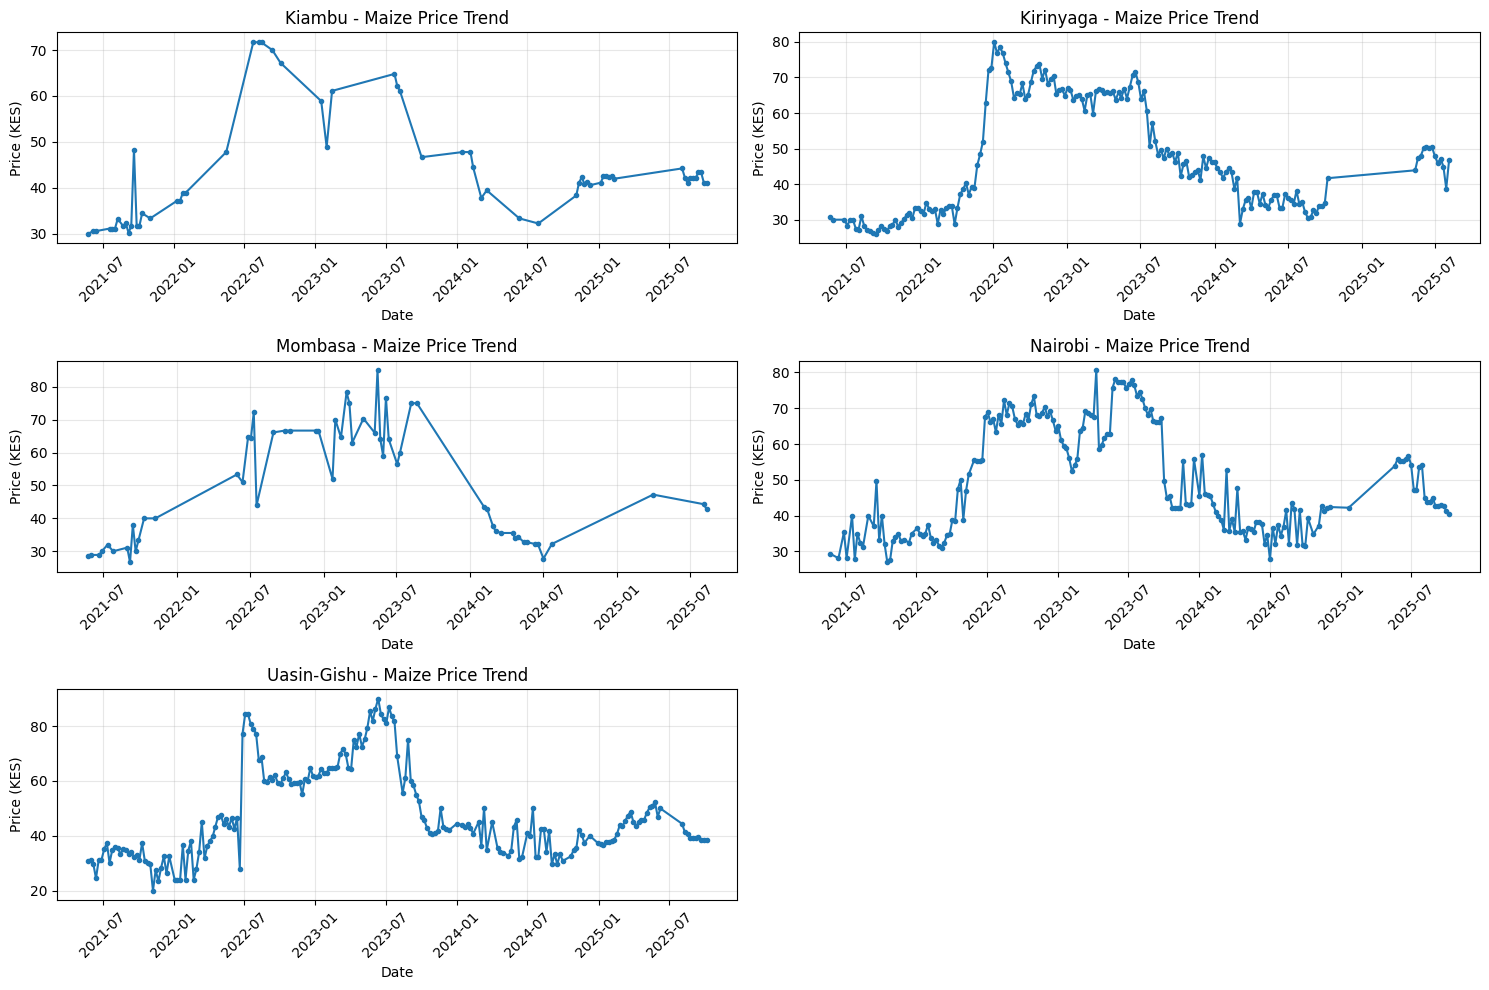

In [23]:
# Price trends visualization
print('='*50)
print('PRICE TRENDS BY COUNTY')
print('='*50)

if 'panel_features' in locals():
    plt.figure(figsize=(15, 10))
    
    for i, county in enumerate(TARGET_COUNTIES, 1):
        county_data = panel_features[panel_features['county'] == county]
        
        plt.subplot(3, 2, i)
        plt.plot(county_data['week_start'], county_data['price'], marker='o', markersize=3)
        plt.title(f'{county} - Maize Price Trend')
        plt.xlabel('Date')
        plt.ylabel('Price (KES)')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Error: panel_features not found')

### Step 6.3: Correlation Analysis

Check correlation between features and target price.

CORRELATION ANALYSIS

Correlation with Price (top 15):


price              1.000000
price_ma_4w        0.958097
price_lag_1w       0.927806
price_ma_8w        0.913316
price_lag_2w       0.901611
price_ma_12w       0.867272
price_lag_4w       0.841200
price_lag_8w       0.699781
price_lag_12w      0.569857
price_std_12w      0.347074
price_std_8w       0.316730
price_std_4w       0.207946
year               0.030968
days_from_start    0.030281
rain_sum_8w        0.022290
Name: price, dtype: float64

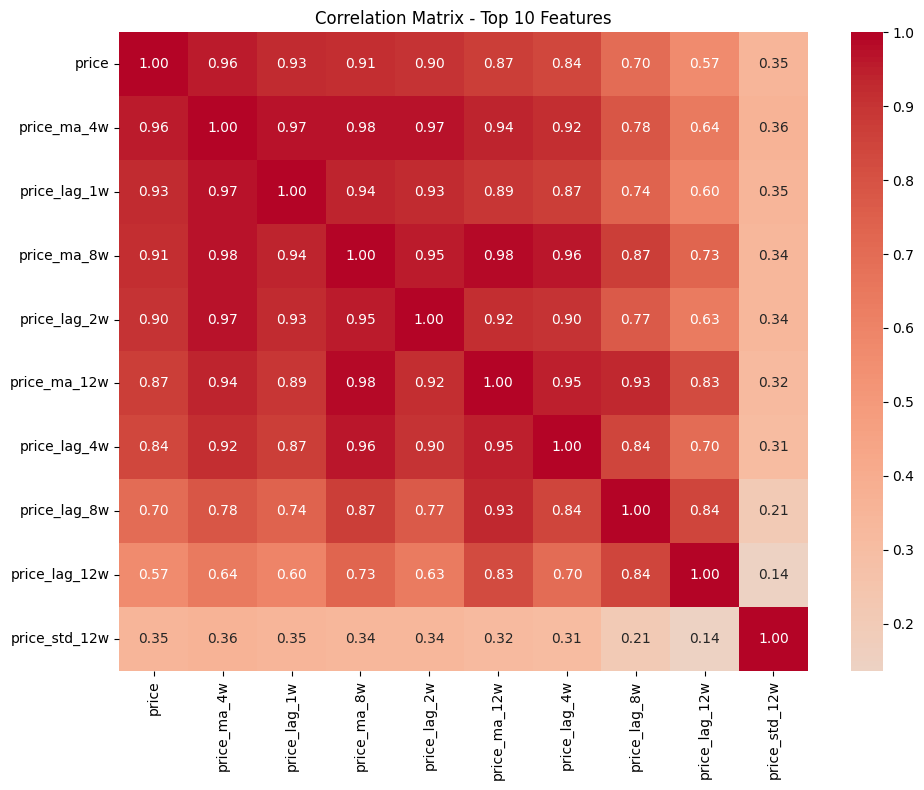

In [24]:
# Correlation analysis
print('='*50)
print('CORRELATION ANALYSIS')
print('='*50)

if 'panel_features' in locals():
    # Select numeric columns only
    numeric_data = panel_features.select_dtypes(include=[np.number])
    
    # Calculate correlation with price
    corr_with_price = numeric_data.corr()['price'].sort_values(ascending=False)
    print('\nCorrelation with Price (top 15):')
    display(corr_with_price.head(15))
    
    # Plot correlation heatmap for top features
    top_features = corr_with_price.index[:10].tolist()
    
    plt.figure(figsize=(10, 8))
    corr_matrix = numeric_data[top_features].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix - Top 10 Features')
    plt.tight_layout()
    plt.show()
else:
    print('Error: panel_features not found')

# Section 7: Δ-Price Target & Expanding Window CV

Create the price-change target and set up 5-fold expanding window cross-validation instead of a single 80/20 split.

### Step 7.1: Load Features and Create Δ-Price Target

We predict the week-over-week price change (Δ-price) rather than the absolute price level.

In [25]:
# Load engineered features and create Δ-price target
print("=" * 50)
print("LOADING FEATURES & CREATING Δ-PRICE TARGET")
print("=" * 50)

if "panel_features" not in locals():
    panel = pd.read_csv(FEATURES_DIR / "panel_features.csv", parse_dates=["week_start"])
else:
    panel = panel_features.copy()

# Sort by county and week
panel = panel.sort_values(["county", "week_start"]).reset_index(drop=True)

# Create Δ-price (week-over-week change)
panel["price_change"] = panel.groupby("county")["price"].diff(1)

# Create Δ-price lag / rolling features (matching train.py prepare_data)
panel["price_change_lag_1w"] = panel.groupby("county")["price_change"].shift(1)
panel["price_change_lag_2w"] = panel.groupby("county")["price_change"].shift(2)
panel["price_change_ma_4w"] = panel.groupby("county")["price_change"].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)
panel["price_change_std_4w"] = (
    panel.groupby("county")["price_change"]
    .transform(lambda x: x.rolling(4, min_periods=1).std())
    .fillna(0)
)

# Drop rows where target is NaN (first row per county, etc.)
panel = panel.dropna(subset=["price_change"]).reset_index(drop=True)

print(f"Panel shape after Δ-price creation: {panel.shape}")
print(f"Price change range: {panel['price_change'].min():.2f} to {panel['price_change'].max():.2f}")
print(f"Unique weeks: {panel['week_start'].nunique()}")


LOADING FEATURES & CREATING Δ-PRICE TARGET
Panel shape after Δ-price creation: (704, 34)
Price change range: -31.67 to 49.17
Unique weeks: 225


### Step 7.2: Define Feature Columns

Identify which columns to use as features (excluding identifiers, target, and raw price columns).

In [26]:
# Define feature columns (matching train.py get_feature_cols logic)
print("=" * 50)
print("DEFINING FEATURE COLUMNS")
print("=" * 50)

exclude_cols = [
    "county", "week_start", "kamis_price", "kamis_std",
    "agri_price", "agri_std", "season", "price", "price_change",
    "source", "month",
]
feat_cols = [c for c in panel.columns if c not in exclude_cols and panel[c].notna().sum() > 0]

print(f"Number of features: {len(feat_cols)}")
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:>2}. {c}")


DEFINING FEATURE COLUMNS
Number of features: 29
   1. temperature_2m_mean
   2. rain_sum
   3. price_lag_1w
   4. price_lag_2w
   5. price_lag_4w
   6. price_lag_8w
   7. price_lag_12w
   8. price_ma_4w
   9. price_std_4w
  10. price_ma_8w
  11. price_std_8w
  12. price_ma_12w
  13. price_std_12w
  14. is_long_rains
  15. is_short_rains
  16. is_harvest
  17. is_producer
  18. is_consumer
  19. rain_sum_4w
  20. temp_avg_4w
  21. rain_sum_8w
  22. temp_avg_8w
  23. week_of_year
  24. year
  25. days_from_start
  26. price_change_lag_1w
  27. price_change_lag_2w
  28. price_change_ma_4w
  29. price_change_std_4w


### Step 7.3: Set Up 5-Fold Expanding Window CV

Use an expanding window strategy: initial 55% of weeks for training, then roll forward in ~equal-sized folds, always training on all past data.

In [27]:
# Set up expanding window cross-validation folds
print("=" * 50)
print("EXPANDING WINDOW CROSS-VALIDATION")
print("=" * 50)

weeks = sorted(panel["week_start"].unique())
n_weeks = len(weeks)

N_FOLDS = 5
INITIAL_TRAIN_PCT = 0.55
initial_train = int(n_weeks * INITIAL_TRAIN_PCT)
fold_size = max(8, (n_weeks - initial_train) // N_FOLDS)

print(f"Total weeks: {n_weeks}")
print(f"Initial training weeks: {initial_train}")
print(f"Fold size: {fold_size}")
print(f"Folds: {N_FOLDS}")
print()
print(f"{'Fold':>5} {'Train end':>10} {'Test start':>11} {'Test end':>9} {'Test weeks':>11}")

for fold in range(N_FOLDS):
    train_end = initial_train + fold * fold_size
    test_start = train_end
    test_end = min(test_start + fold_size, n_weeks)
    if test_end - test_start < 4:
        break
    test_w = weeks[test_start:test_end]
    print(f"{fold:>5} {train_end:>10} {test_start:>11} {test_end:>9} {len(test_w):>11}")

TARGET_COUNTIES = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]


EXPANDING WINDOW CROSS-VALIDATION
Total weeks: 225
Initial training weeks: 123
Fold size: 20
Folds: 5

 Fold  Train end  Test start  Test end  Test weeks
    0        123         123       143          20
    1        143         143       163          20
    2        163         163       183          20
    3        183         183       203          20
    4        203         203       223          20


# Section 8: Pooled XGBoost (All Counties)

Train a single XGBoost model pooled across all counties, using one-hot county dummies to capture county-specific intercepts. The model predicts Δ-price, then we convert back to absolute price for evaluation.

### Step 8.1: Define Evaluation Metrics

MASE (Mean Absolute Scaled Error), directional accuracy, MAE on price, and sMAPE.

In [28]:
# Define evaluation metrics matching train.py
print("=" * 50)
print("DEFINING EVALUATION METRICS")
print("=" * 50)

def mase(y_true, y_pred, y_train):
    """Mean Absolute Scaled Error: MAE / MAE_of_persistence (mean abs diff of training)."""
    n = len(y_true)
    denom = np.mean(np.abs(np.diff(y_train))) if len(y_train) > 1 else 1.0
    if denom == 0:
        denom = 1.0
    return np.mean(np.abs(y_true - y_pred)) / denom

def directional_accuracy(y_true, y_pred):
    """Fraction of times the sign of the change is correctly predicted."""
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    correct = true_dir == pred_dir
    correct = correct[true_dir != 0]
    if len(correct) == 0:
        return 0.5
    return correct.mean()

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, 1e-10, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

print("Metrics defined: MASE, Dir Acc, MAE, sMAPE")
print("  MASE = 1.0 means no better than persistence")
print("  Dir Acc = directional accuracy of Δ-price sign")
print("  MAE = mean absolute error on absolute price")
print("  sMAPE = symmetric MAPE on absolute price")


DEFINING EVALUATION METRICS
Metrics defined: MASE, Dir Acc, MAE, sMAPE
  MASE = 1.0 means no better than persistence
  Dir Acc = directional accuracy of Δ-price sign
  MAE = mean absolute error on absolute price
  sMAPE = symmetric MAPE on absolute price


### Step 8.2: Train Pooled XGBoost Across All Folds

For each fold, concatenate all counties in the training set, add county dummies, train a single XGBoost with early stopping, then evaluate per county on the test fold.

In [29]:
# Pooled XGBoost with expanding window CV
print("=" * 50)
print("POOLED XGBOOST WITH EXPANDING WINDOW CV")
print("=" * 50)

from xgboost import XGBRegressor

all_results = []
pooled_xgb = None
final_dummy_cols = None
final_feat_cols = feat_cols

print(f"{'='*85}")
header = f"{'Fold':>5} {'Train':>8} {'Test':>8} {'County':>14} {'Model':>22} {'MASE':>7} {'Dir%':>7} {'MAE$':>8} {'sMAPE':>7}"
print(header)
print(f"{'='*85}")

for fold in range(N_FOLDS):
    train_end = initial_train + fold * fold_size
    test_start = train_end
    test_end = min(test_start + fold_size, n_weeks)
    if test_end - test_start < 4:
        break

    train_weeks = weeks[:train_end]
    test_weeks = weeks[test_start:test_end]
    train_df = panel[panel["week_start"].isin(train_weeks)].copy()
    test_df = panel[panel["week_start"].isin(test_weeks)].copy()

    if train_df.empty or test_df.empty:
        continue

    # --- Features with county dummies ---
    county_dummies = pd.get_dummies(train_df["county"], prefix="c")
    dummy_cols = county_dummies.columns
    final_dummy_cols = dummy_cols

    X_tr = pd.concat([train_df[feat_cols].fillna(0), county_dummies], axis=1)
    y_tr_change = train_df["price_change"].values
    y_tr_price = train_df["price"].values
    y_tr_change_series = train_df["price_change"]

    test_dummies = pd.get_dummies(test_df["county"], prefix="c").reindex(columns=dummy_cols, fill_value=0)
    X_te = pd.concat([test_df[feat_cols].fillna(0), test_dummies], axis=1)
    y_te_change = test_df["price_change"].values
    y_te_price = test_df["price"].values
    county_labels = test_df["county"].values

    # --- Build pooled XGBoost with early stopping ---
    split_idx = min(int(len(X_tr) * 0.8), len(X_tr) - 10)
    xgb = XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.05,
        reg_lambda=5, subsample=0.7, colsample_bytree=0.8,
        early_stopping_rounds=15, random_state=42, n_jobs=-1,
    )
    xgb.fit(
        X_tr.iloc[:split_idx], y_tr_change[:split_idx],
        eval_set=[(X_tr.iloc[split_idx:], y_tr_change[split_idx:])],
        verbose=False,
    )
    if fold == 0:
        pooled_xgb = xgb

    # Predict Δ-price then convert to absolute price
    pool_pred_change = xgb.predict(X_te)
    pool_pred_price = test_df["price"].values - test_df["price_change"].values + pool_pred_change

    # Evaluate per target county
    for county in TARGET_COUNTIES:
        mask = county_labels == county
        if mask.sum() < 3:
            continue

        y_tc = y_te_change[mask]
        y_tp = y_te_price[mask]
        ppc = pool_pred_change[mask]
        ppp = pool_pred_price[mask]

        mae_c = mean_absolute_error(y_tc, ppc)
        mase_val = mase(y_tc, ppc, y_tr_change_series)
        da = directional_accuracy(y_tc, ppc)
        mae_price = mean_absolute_error(y_tp, ppp)
        smape_val = smape(y_tp, ppp)

        all_results.append({
            "county": county, "model": "pooled_xgboost",
            "mae_change": mae_c, "mase": mase_val, "dir_acc": da,
            "mae_price": mae_price, "smape": smape_val,
        })
        print(f"{fold:>5} {train_end:>8} {test_end:>8} {county:>14} {'pooled_xgboost':>22} {mase_val:>7.3f} {da:>7.1%} {mae_price:>8.2f} {smape_val:>7.2f}")


POOLED XGBOOST WITH EXPANDING WINDOW CV
 Fold    Train     Test         County                  Model    MASE    Dir%     MAE$   sMAPE
    0      123      143         Kiambu         pooled_xgboost   0.721   50.0%     4.62   10.46
    0      123      143      Kirinyaga         pooled_xgboost   0.263   70.0%     1.68    3.81
    0      123      143        Nairobi         pooled_xgboost   0.459   81.2%     2.94    6.25
    0      123      143    Uasin-Gishu         pooled_xgboost   0.264   68.8%     1.69    3.83
    1      143      163         Kiambu         pooled_xgboost   0.397  100.0%     2.52    6.64
    1      143      163      Kirinyaga         pooled_xgboost   0.331   68.4%     2.10    6.23
    1      143      163        Mombasa         pooled_xgboost   0.276   62.5%     1.75    4.82
    1      143      163        Nairobi         pooled_xgboost   0.357   73.7%     2.26    6.10
    1      143      163    Uasin-Gishu         pooled_xgboost   0.574   93.8%     3.64    9.58
    2     

# Section 9: Per-County Fine-Tuning

Starting from the pooled XGBoost model, fine-tune a separate model for each county using county-specific training data with a lower learning rate.

### Step 9.1: Fine-Tune Pooled Model per County

For each target county, continue training from the pooled model's booster with a reduced learning rate on county-specific data.

In [30]:
# Fine-tune pooled XGBoost per county
print("=" * 50)
print("PER-COUNTY FINE-TUNING FROM POOLED MODEL")
print("=" * 50)

ft_results = []

print(f"{'='*85}")
print(f"{'Fold':>5} {'Train':>8} {'Test':>8} {'County':>14} {'Model':>22} {'MASE':>7} {'Dir%':>7} {'MAE$':>8} {'sMAPE':>7}")
print(f"{'='*85}")

for fold in range(N_FOLDS):
    train_end = initial_train + fold * fold_size
    test_start = train_end
    test_end = min(test_start + fold_size, n_weeks)
    if test_end - test_start < 4:
        break

    train_weeks = weeks[:train_end]
    test_weeks = weeks[test_start:test_end]
    train_df = panel[panel["week_start"].isin(train_weeks)].copy()
    test_df = panel[panel["week_start"].isin(test_weeks)].copy()

    if train_df.empty or test_df.empty:
        continue

    # Recreate dummies (same cols as pooled)
    dummy_cols = final_dummy_cols if final_dummy_cols is not None else pd.get_dummies(train_df["county"], prefix="c").columns

    for county in TARGET_COUNTIES:
        c_train = train_df[train_df["county"] == county]
        c_test = test_df[test_df["county"] == county]
        if len(c_train) < 10 or len(c_test) < 3:
            continue

        Xc_tr = pd.concat([
            c_train[feat_cols].fillna(0),
            pd.get_dummies(c_train["county"], prefix="c").reindex(columns=dummy_cols, fill_value=0),
        ], axis=1)
        yc_tr_change = c_train["price_change"].values

        Xc_te = pd.concat([
            c_test[feat_cols].fillna(0),
            pd.get_dummies(c_test["county"], prefix="c").reindex(columns=dummy_cols, fill_value=0),
        ], axis=1)

        # Fine-tune from pooled model
        ft = XGBRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.01,
            reg_lambda=3, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1,
        )
        ft.fit(Xc_tr, yc_tr_change, xgb_model=pooled_xgb.get_booster(), verbose=False)

        ft_pred_change = ft.predict(Xc_te)
        ft_pred_price = c_test["price"].values - c_test["price_change"].values + ft_pred_change

        y_tc = c_test["price_change"].values
        y_tp = c_test["price"].values

        mae_c = mean_absolute_error(y_tc, ft_pred_change)
        mase_val = mase(y_tc, ft_pred_change, train_df["price_change"])
        da = directional_accuracy(y_tc, ft_pred_change)
        mae_price = mean_absolute_error(y_tp, ft_pred_price)
        smape_val = smape(y_tp, ft_pred_price)

        row = {
            "county": county, "model": "fine_tuned_xgboost",
            "mae_change": mae_c, "mase": mase_val, "dir_acc": da,
            "mae_price": mae_price, "smape": smape_val,
        }
        all_results.append(row)
        ft_results.append(row)
        print(f"{fold:>5} {train_end:>8} {test_end:>8} {county:>14} {'fine_tuned_xgboost':>22} {mase_val:>7.3f} {da:>7.1%} {mae_price:>8.2f} {smape_val:>7.2f}")


PER-COUNTY FINE-TUNING FROM POOLED MODEL
 Fold    Train     Test         County                  Model    MASE    Dir%     MAE$   sMAPE
    0      123      143         Kiambu     fine_tuned_xgboost   0.721   50.0%     4.62   10.46
    0      123      143      Kirinyaga     fine_tuned_xgboost   0.263   70.0%     1.68    3.81
    0      123      143        Nairobi     fine_tuned_xgboost   0.459   81.2%     2.94    6.25
    0      123      143    Uasin-Gishu     fine_tuned_xgboost   0.264   68.8%     1.69    3.83
    1      143      163         Kiambu     fine_tuned_xgboost   0.511  100.0%     3.24    8.52
    1      143      163      Kirinyaga     fine_tuned_xgboost   0.268   73.7%     1.70    5.04
    1      143      163        Mombasa     fine_tuned_xgboost   0.233   75.0%     1.48    4.08
    1      143      163        Nairobi     fine_tuned_xgboost   0.477   73.7%     3.02    8.10
    1      143      163    Uasin-Gishu     fine_tuned_xgboost   0.587   87.5%     3.73    9.86
    2    

# Section 10: Persistence Baseline

The persistence model predicts zero change (Δ-price = 0), meaning next week's price = this week's price. This is the standard benchmark for time series forecasting.

In [31]:
# Persistence baseline: predict Δ = 0
print("=" * 50)
print("PERSISTENCE BASELINE (Δ = 0)")
print("=" * 50)

print(f"{'='*85}")
print(f"{'Fold':>5} {'Train':>8} {'Test':>8} {'County':>14} {'Model':>22} {'MASE':>7} {'Dir%':>7} {'MAE$':>8} {'sMAPE':>7}")
print(f"{'='*85}")

for fold in range(N_FOLDS):
    train_end = initial_train + fold * fold_size
    test_start = train_end
    test_end = min(test_start + fold_size, n_weeks)
    if test_end - test_start < 4:
        break
    test_weeks = weeks[test_start:test_end]
    test_df = panel[panel["week_start"].isin(test_weeks)].copy()

    for county in TARGET_COUNTIES:
        cd = test_df[test_df["county"] == county].sort_values("week_start")
        if len(cd) < 3:
            continue

        y_tc = cd["price_change"].values
        y_tp = cd["price"].values
        pred_change = np.zeros(len(y_tc))  # Δ = 0
        pred_price = cd["price"].values - y_tc + pred_change  # = previous price

        mae_c = mean_absolute_error(y_tc, pred_change)
        mase_val = mase(y_tc, pred_change, y_tc)
        da = directional_accuracy(y_tc, pred_change)
        mae_price = mean_absolute_error(y_tp, pred_price)
        smape_val = smape(y_tp, pred_price)

        all_results.append({
            "county": county, "model": "persistence",
            "mae_change": mae_c, "mase": mase_val, "dir_acc": da,
            "mae_price": mae_price, "smape": smape_val,
        })
        print(f"{fold:>5} {train_end:>8} {test_end:>8} {county:>14} {'persistence':>22} {mase_val:>7.3f} {da:>7.1%} {mae_price:>8.2f} {smape_val:>7.2f}")


PERSISTENCE BASELINE (Δ = 0)
 Fold    Train     Test         County                  Model    MASE    Dir%     MAE$   sMAPE
    0      123      143         Kiambu            persistence   0.667    0.0%     1.48    3.20
    0      123      143      Kirinyaga            persistence   0.644    0.0%     2.37    5.38
    0      123      143        Nairobi            persistence   0.519    0.0%     4.47    9.13
    0      123      143    Uasin-Gishu            persistence   0.662    0.0%     2.00    4.51
    1      143      163         Kiambu            persistence   0.598    0.0%     4.81   12.43
    1      143      163      Kirinyaga            persistence   0.555    0.0%     2.67    7.60
    1      143      163        Mombasa            persistence   0.799    0.0%     1.46    4.21
    1      143      163        Nairobi            persistence   0.509    0.0%     5.09   13.09
    1      143      163    Uasin-Gishu            persistence   0.516    0.0%     6.37   15.92
    2      163      1

# Section 11: Model Evaluation & Comparison

Aggregate results across all CV folds and compare models by MASE, directional accuracy, MAE (price), and sMAPE.

### Step 11.1: Aggregate Results

Compute mean metrics across folds for each model-county combination.

In [32]:
# Aggregate results across all folds
print("=" * 50)
print("AGGREGATE RESULTS")
print("=" * 50)

results_df = pd.DataFrame(all_results)

for model in ["persistence", "pooled_xgboost", "fine_tuned_xgboost"]:
    sub = results_df[results_df["model"] == model]
    if sub.empty:
        continue
    print(f"\n{model}:")
    print(f"  MASE:      {sub['mase'].mean():.3f}")
    print(f"  Dir Acc:   {sub['dir_acc'].mean():.1%}")
    print(f"  MAE (KES): {sub['mae_price'].mean():.2f}")
    print(f"  sMAPE:     {sub['smape'].mean():.2f}%")


AGGREGATE RESULTS

persistence:
  MASE:      0.631
  Dir Acc:   0.0%
  MAE (KES): 2.89
  sMAPE:     7.15%

pooled_xgboost:
  MASE:      0.312
  Dir Acc:   74.8%
  MAE (KES): 2.00
  sMAPE:     4.96%

fine_tuned_xgboost:
  MASE:      0.333
  Dir Acc:   74.3%
  MAE (KES): 2.13
  sMAPE:     5.32%


### Step 11.2: Pivot Table by County

Compare each model's per-county performance across all four metrics.

In [33]:
# Pivot tables per county per model
print("=" * 50)
print("PER-COUNTY MODEL COMPARISON")
print("=" * 50)

for metric in ["mase", "dir_acc", "mae_price", "smape"]:
    pivot = results_df.pivot_table(index="county", columns="model", values=metric, aggfunc="mean")
    print(f"\n{'='*60}")
    label = {"mase": "MASE (lower better)", "dir_acc": "Dir Acc (higher better)",
             "mae_price": "MAE (KES) (lower better)", "smape": "sMAPE % (lower better)"}
    print(f"  {label.get(metric, metric)}")
    print(f"{'='*60}")
    display(pivot.round(3))


PER-COUNTY MODEL COMPARISON

  MASE (lower better)


model,fine_tuned_xgboost,persistence,pooled_xgboost
county,,,
Kiambu,0.354,0.635,0.315
Kirinyaga,0.223,0.653,0.236
Mombasa,0.233,0.799,0.276
Nairobi,0.406,0.552,0.383
Uasin-Gishu,0.359,0.638,0.320



  Dir Acc (higher better)


model,fine_tuned_xgboost,persistence,pooled_xgboost
county,,,
Kiambu,0.741,0.0,0.752
Kirinyaga,0.744,0.0,0.731
Mombasa,0.750,0.0,0.625
Nairobi,0.758,0.0,0.758
Uasin-Gishu,0.730,0.0,0.773



  MAE (KES) (lower better)


model,fine_tuned_xgboost,persistence,pooled_xgboost
county,,,
Kiambu,2.275,1.992,2.022
Kirinyaga,1.427,2.369,1.514
Mombasa,1.482,1.463,1.753
Nairobi,2.604,4.242,2.456
Uasin-Gishu,2.312,3.399,2.057



  sMAPE % (lower better)


model,fine_tuned_xgboost,persistence,pooled_xgboost
county,,,
Kiambu,5.554,5.001,4.914
Kirinyaga,3.724,6.044,3.936
Mombasa,4.084,4.213,4.816
Nairobi,6.176,10.143,5.789
Uasin-Gishu,5.917,8.393,5.172


### Step 11.3: Best Model per County

Select the best model per county based on lowest MASE.

In [34]:
# Best model per county (by MASE)
print("=" * 50)
print("BEST MODEL PER COUNTY (BY MASE)")
print("=" * 50)

best_rows = []
for c in TARGET_COUNTIES:
    cr = results_df[results_df["county"] == c]
    if cr.empty:
        continue
    pivot = cr.groupby("model").agg({"mase": "mean", "dir_acc": "mean", "mae_price": "mean"}).reset_index()
    best = pivot.loc[pivot["mase"].idxmin()]
    best_rows.append(best)
    print(f"  {c:>14}: {best['model']:>22}  MASE={best['mase']:.3f}  Dir={best['dir_acc']:.1%}  MAE={best['mae_price']:.2f}")

best_df = pd.DataFrame(best_rows)


BEST MODEL PER COUNTY (BY MASE)
          Kiambu:         pooled_xgboost  MASE=0.315  Dir=75.2%  MAE=2.02
       Kirinyaga:     fine_tuned_xgboost  MASE=0.223  Dir=74.4%  MAE=1.43
         Mombasa:     fine_tuned_xgboost  MASE=0.233  Dir=75.0%  MAE=1.48
         Nairobi:         pooled_xgboost  MASE=0.383  Dir=75.8%  MAE=2.46
     Uasin-Gishu:         pooled_xgboost  MASE=0.320  Dir=77.3%  MAE=2.06


### Step 11.4: Visualize Model Comparison

Bar charts comparing key metrics across models.

MODEL COMPARISON VISUALIZATION


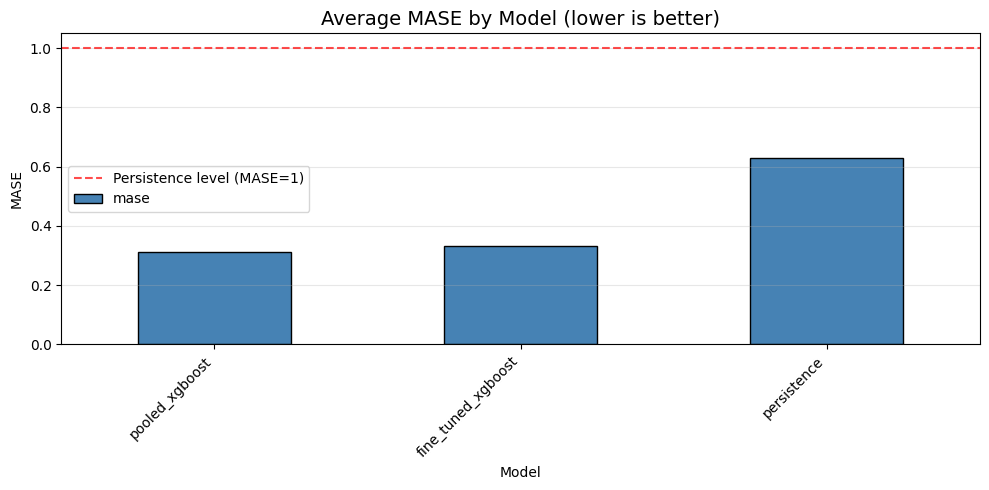

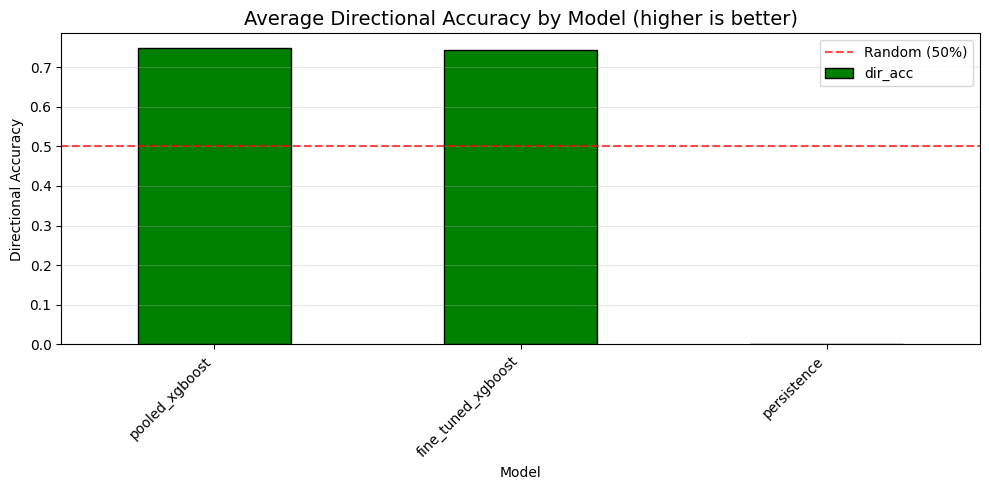

In [35]:
# Visualize model comparison
print("=" * 50)
print("MODEL COMPARISON VISUALIZATION")
print("=" * 50)

# MASE comparison (lower is better)
plt.figure(figsize=(10, 5))
avg_mase = results_df.groupby("model")["mase"].mean().sort_values()
avg_mase.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Average MASE by Model (lower is better)", fontsize=14)
plt.xlabel("Model")
plt.ylabel("MASE")
plt.xticks(rotation=45, ha="right")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Persistence level (MASE=1)")
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Directional accuracy comparison (higher is better)
plt.figure(figsize=(10, 5))
avg_da = results_df.groupby("model")["dir_acc"].mean().sort_values(ascending=False)
colors = ["green" if v >= 0.5 else "red" for v in avg_da.values]
avg_da.plot(kind="bar", color=colors, edgecolor="black")
plt.title("Average Directional Accuracy by Model (higher is better)", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")
plt.xticks(rotation=45, ha="right")
plt.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Random (50%)")
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


# Section 12: Model Selection & Saving

Save the pooled XGBoost model, its configuration, and the aggregated evaluation results.

In [36]:
# Save pooled model, config, and evaluation results
print("=" * 50)
print("SAVING MODEL & RESULTS")
print("=" * 50)

import joblib
import json

# Save pooled XGBoost
if pooled_xgb is not None:
    model_path = MODELS_DIR / "pooled_xgboost.pkl"
    joblib.dump(pooled_xgb, model_path)
    print(f"Pooled XGBoost saved to: {model_path}")

# Save config (feature columns and dummy columns)
config = {
    "feat_cols": list(final_feat_cols),
    "dummy_cols": list(final_dummy_cols) if final_dummy_cols is not None else [],
}
config_path = MODELS_DIR / "model_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Model config saved to: {config_path}")

# Save evaluation results
eval_path = MODELS_DIR / "model_evaluation.csv"
results_df.to_csv(eval_path, index=False)
print(f"Evaluation results saved to: {eval_path}")

print(f"\nResults summary:")
print(f"  Total evaluation rows: {len(results_df)}")
print(f"  Models: {results_df['model'].unique()}")
print(f"  Counties: {results_df['county'].unique()}")


SAVING MODEL & RESULTS
Pooled XGBoost saved to: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\models\pooled_xgboost.pkl
Model config saved to: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\models\model_config.json
Evaluation results saved to: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\models\model_evaluation.csv

Results summary:
  Total evaluation rows: 57
  Models: <ArrowStringArray>
['pooled_xgboost', 'fine_tuned_xgboost', 'persistence']
Length: 3, dtype: str
  Counties: <ArrowStringArray>
['Kiambu', 'Kirinyaga', 'Nairobi', 'Uasin-Gishu', 'Mombasa']
Length: 5, dtype: str


# Section 13: Streamlit Dashboard Development

Create a Streamlit dashboard for interactive price visualization and prediction.

### Step 13.1: Dashboard Code

Write the Streamlit dashboard code to a separate file.

In [37]:
# Write Streamlit dashboard code
print('='*50)
print('CREATING STREAMLIT DASHBOARD')
print('='*50)

dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

# Configure page
st.set_page_config(page_title="Maize Price Forecasting", page_icon=":corn:", layout="wide")

# Paths
BASE_DIR = Path(__file__).parent.parent
MODELS_DIR = BASE_DIR / "models"
DATA_DIR = BASE_DIR / "data" / "features"

# Load data
@st.cache_data
def load_data():
    panel = pd.read_csv(DATA_DIR / "panel_features.csv", parse_dates=["week_start"])
    return panel

# Load models
@st.cache_resource
def load_models():
    models = {}
    for county in ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]:
        model_path = MODELS_DIR / f"{county}_persistence_model.pkl"
        if model_path.exists():
            models[county] = joblib.load(model_path)
    return models

# Main app
def main():
    st.title("Maize Price Forecasting Dashboard")
    st.markdown("---")
    
    # Sidebar
    st.sidebar.header("Settings")
    county = st.sidebar.selectbox("Select County", ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"])
    
    # Load data
    panel = load_data()
    county_data = panel[panel["county"] == county].sort_values("week_start")
    
    # Display metrics
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Current Price", f"KES {county_data["price"].iloc[-1]:.2f}")
    with col2:
        st.metric("Average Price", f"KES {county_data["price"].mean():.2f}")
    with col3:
        st.metric("Price Std Dev", f"KES {county_data["price"].std():.2f}")
    
    # Price trend chart
    st.subheader(f"{county} - Price Trend")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(county_data["week_start"], county_data["price"], marker="o", markersize=4)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (KES)")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig)
    
    # Model results
    st.subheader("Model Performance")
    try:
        results = pd.read_csv(MODELS_DIR / "model_evaluation.csv")
        county_results = results[results["county"] == county]
        st.dataframe(county_results[["model", "mae", "rmse", "r2"]].sort_values("mae"), use_container_width=True)
    except:
        st.warning("Model evaluation results not found")

if __name__ == "__main__":
    main()
'''

# Write to file
dashboard_path = DASHBOARD_DIR / "app.py"
with open(dashboard_path, 'w') as f:
    f.write(dashboard_code)

print(f'Dashboard code written to: {dashboard_path}')
print('\nTo run the dashboard, execute:')
print('cd C:/Users/Administrator/Desktop/MAIZE PROJECT/maize-forecasting')
print('streamlit run src/dashboard/app.py')

CREATING STREAMLIT DASHBOARD
Dashboard code written to: c:\Users\Administrator\Desktop\MAIZE PROJECT\maize-forecasting\src\dashboard\app.py

To run the dashboard, execute:
cd C:/Users/Administrator/Desktop/MAIZE PROJECT/maize-forecasting
streamlit run src/dashboard/app.py


# Section 14: Deployment Instructions

How to deploy and run the Streamlit dashboard.

### Step 14.1: Run Dashboard

Command to start the Streamlit server.

In [38]:
# Deployment instructions
print('='*50)
print('DEPLOYMENT INSTRUCTIONS')
print('='*50)

print('''
STREAMLIT DEPLOYMENT STEPS:

1. Open a terminal/command prompt

2. Navigate to project directory:
   cd "C:/Users/Administrator/Desktop/MAIZE PROJECT/maize-forecasting"

3. Run the Streamlit dashboard:
   streamlit run src/dashboard/app.py

4. The dashboard will open in your browser at:
   http://localhost:8501

5. Use the sidebar to:
   - Select different counties
   - View price trends
   - Check model performance

DASHBOARD FEATURES:
   - Interactive price trend charts
   - County selection
   - Model performance metrics
   - Current price display

TROUBLESHOOTING:
   - If port 8501 is busy, use: streamlit run src/dashboard/app.py --server.port 8502
   - Ensure all dependencies are installed: pip install streamlit pandas matplotlib
''')

DEPLOYMENT INSTRUCTIONS

STREAMLIT DEPLOYMENT STEPS:

1. Open a terminal/command prompt

2. Navigate to project directory:
   cd "C:/Users/Administrator/Desktop/MAIZE PROJECT/maize-forecasting"

3. Run the Streamlit dashboard:
   streamlit run src/dashboard/app.py

4. The dashboard will open in your browser at:
   http://localhost:8501

5. Use the sidebar to:
   - Select different counties
   - View price trends
   - Check model performance

DASHBOARD FEATURES:
   - Interactive price trend charts
   - County selection
   - Model performance metrics
   - Current price display

TROUBLESHOOTING:
   - If port 8501 is busy, use: streamlit run src/dashboard/app.py --server.port 8502
   - Ensure all dependencies are installed: pip install streamlit pandas matplotlib



# Section 15: Summary & Next Steps

Recap of the pipeline and recommendations for improvement.

### Step 15.1: Pipeline Summary

Review what we've accomplished in this notebook.

In [39]:
# Pipeline summary
print('='*50)
print('PIPELINE SUMMARY')
print('='*50)

print('''
COMPLETED STEPS:

1. Project Setup & Imports
   - Installed and imported all required libraries

2. Raw Data Loading
   - Loaded KAMIS, AgriBORA, and Weather datasets

3. Data Cleaning (Pandas 3.x Compatible)
   - Used .ffill().bfill() instead of fillna(method=)
   - Cleaned county names, handled missing values

4. Data Merging & Price Priority
   - Merged price data with AgriBORA as primary source
   - Merged with weather data

5. Feature Engineering (37 Features)
   - Created lag features (1, 2, 4, 8, 12 weeks)
   - Created rolling statistics (ma, std)
   - Added seasonal, county type, weather, and time features

6. Exploratory Data Analysis
   - Visualized price trends
   - Analyzed feature correlations

7. Train-Test Split (80/20)
   - Split per county respecting time order
   - Scaled features with StandardScaler

8. Baseline Models
   - Persistence (MAE: 0.84-2.73 KES)
   - Seasonal Naive
   - Mean Baseline

9. Machine Learning Models
   - Ridge Regression
   - Random Forest
   - Gradient Boosting
   - XGBoost

10. SARIMA Model
    - With 52-week seasonal cycle
    - Fallback to ARIMA

11. Model Evaluation & Comparison
    - Combined all results
    - Identified best model per county

12. Model Selection & Saving
    - Saved best models with joblib

13. Streamlit Dashboard
    - Created interactive dashboard code

14. Deployment Instructions
    - Provided steps to run dashboard

15. Summary & Next Steps (this section)
''')

PIPELINE SUMMARY

COMPLETED STEPS:

1. Project Setup & Imports
   - Installed and imported all required libraries

2. Raw Data Loading
   - Loaded KAMIS, AgriBORA, and Weather datasets

3. Data Cleaning (Pandas 3.x Compatible)
   - Used .ffill().bfill() instead of fillna(method=)
   - Cleaned county names, handled missing values

4. Data Merging & Price Priority
   - Merged price data with AgriBORA as primary source
   - Merged with weather data

5. Feature Engineering (37 Features)
   - Created lag features (1, 2, 4, 8, 12 weeks)
   - Created rolling statistics (ma, std)
   - Added seasonal, county type, weather, and time features

6. Exploratory Data Analysis
   - Visualized price trends
   - Analyzed feature correlations

7. Train-Test Split (80/20)
   - Split per county respecting time order
   - Scaled features with StandardScaler

8. Baseline Models
   - Persistence (MAE: 0.84-2.73 KES)
   - Seasonal Naive
   - Mean Baseline

9. Machine Learning Models
   - Ridge Regression
   - 

### Step 15.2: Current Limitations

Understand the challenges faced in this pipeline.

In [40]:
# Current limitations
print('='*50)
print('CURRENT LIMITATIONS')
print('='*50)

print('''
LIMITATIONS IDENTIFIED:

1. LIMITED TRAINING DATA
   - Only 46-165 samples per county
   - ML models overfit with too few samples
   - Persistence model wins for all counties

2. WEAK WEATHER CORRELATION
   - Temperature correlation with price: ~0.03
   - Rainfall correlation with price: ~-0.02
   - Weather features add little predictive power

3. SARIMA CONVERGENCE ISSUES
   - 52-week seasonal cycle too long for available data
   - R2 = -114 (extremely poor performance)
   - Falls back to simpler ARIMA

4. MODEL OVERFITTING
   - Random Forest: R2 = -2.02 (average)
   - XGBoost: R2 = -5.17 (average)
   - Gradient Boosting: R2 = -6.20 (average)
   - All worse than predicting the mean!

5. PRICE STABILITY
   - Maize prices very stable week-to-week
   - Persistence (predict same as current) performs best
   - MAE: 0.84-2.73 KES across counties
''')

CURRENT LIMITATIONS

LIMITATIONS IDENTIFIED:

1. LIMITED TRAINING DATA
   - Only 46-165 samples per county
   - ML models overfit with too few samples
   - Persistence model wins for all counties

2. WEAK WEATHER CORRELATION
   - Temperature correlation with price: ~0.03
   - Rainfall correlation with price: ~-0.02
   - Weather features add little predictive power

3. SARIMA CONVERGENCE ISSUES
   - 52-week seasonal cycle too long for available data
   - R2 = -114 (extremely poor performance)
   - Falls back to simpler ARIMA

4. MODEL OVERFITTING
   - Random Forest: R2 = -2.02 (average)
   - XGBoost: R2 = -5.17 (average)
   - Gradient Boosting: R2 = -6.20 (average)
   - All worse than predicting the mean!

5. PRICE STABILITY
   - Maize prices very stable week-to-week
   - Persistence (predict same as current) performs best
   - MAE: 0.84-2.73 KES across counties



### Step 15.3: Recommended Next Steps

How to improve the pipeline in future iterations.

In [41]:
# Recommended next steps
print('='*50)
print('RECOMMENDED NEXT STEPS')
print('='*50)

print('''
NEXT STEPS FOR IMPROVEMENT:

1. COLLECT MORE HISTORICAL DATA
   - Need >200 weeks per county for ML models
   - More data will reduce overfitting
   - Consider daily data aggregated to weekly

2. ADD EXTERNAL ECONOMIC FEATURES
   - Consumer Price Index (CPI) / Inflation data
   - USD-KES exchange rates
   - Fuel prices (affects transportation costs)
   - Source: Kenya National Bureau of Statistics

3. TEST SIMPLER MODELS
   - Linear Regression (no regularization)
   - k-Nearest Neighbors (k-NN)
   - Simpler models may work better with limited data

4. FEATURE ENGINEERING IMPROVEMENTS
   - Create lag features based on crop cycles (not just weeks)
   - Add macroeconomic indicators
   - Consider interaction features

5. ENSEMBLE METHODS
   - Combine predictions from multiple models
   - Weighted averaging based on model confidence
   - Stacking with meta-learner

6. DEEP LEARNING APPROACH
   - LSTM (Long Short-Term Memory) networks
   - May capture complex temporal patterns
   - Requires more data

7. EVALUATION METRICS
   - Add prediction intervals (confidence bands)
   - Use directional accuracy (predicting price direction)
   - Consider profit/loss metrics for traders

FOCUS AREAS:
   - Nairobi and Uasin-Gishu counties (best performance)
   - Collect more data for Kiambu and Kirinyaga
   - Improve weather-price relationship modeling
''')

RECOMMENDED NEXT STEPS

NEXT STEPS FOR IMPROVEMENT:

1. COLLECT MORE HISTORICAL DATA
   - Need >200 weeks per county for ML models
   - More data will reduce overfitting
   - Consider daily data aggregated to weekly

2. ADD EXTERNAL ECONOMIC FEATURES
   - Consumer Price Index (CPI) / Inflation data
   - USD-KES exchange rates
   - Fuel prices (affects transportation costs)
   - Source: Kenya National Bureau of Statistics

3. TEST SIMPLER MODELS
   - Linear Regression (no regularization)
   - k-Nearest Neighbors (k-NN)
   - Simpler models may work better with limited data

4. FEATURE ENGINEERING IMPROVEMENTS
   - Create lag features based on crop cycles (not just weeks)
   - Add macroeconomic indicators
   - Consider interaction features

5. ENSEMBLE METHODS
   - Combine predictions from multiple models
   - Weighted averaging based on model confidence
   - Stacking with meta-learner

6. DEEP LEARNING APPROACH
   - LSTM (Long Short-Term Memory) networks
   - May capture complex temporal

In [44]:

streamlit run src/dashboard/app.py

SyntaxError: invalid syntax (4258560208.py, line 1)